# B29 Corridor — MLP Regressor für Kraftstoffpreise

**Strecke:** Aalen → Schwäbisch Gmünd → Schorndorf → Stuttgart  
**Ziel:** Stündliche Kraftstoffpreise je Cluster vorhersagen (48h-Horizont) um den optimalen Tankzeitpunkt auf der B29 zu identifizieren.

Vorgehen nach CRISP-DM (6 Phasen).

In [1]:
# installiere pyarrow und fastparquet für die Verarbeitung von Parquet-Dateien
# %pip install pyarrow fastparquet

In [2]:
import sys, os
sys.path.insert(0, '..')   # project root → makes 'scripts' importable
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

from scripts.data_transform import B29DataLoader, B29_CLUSTERS_DEFAULT

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 42
TARGET_HORIZON = 72
DATA_START_DATE = "2014-06-09"
DATA_END_DATE = "2026-04-01" # Einführung der Spritpreisbremse am 1. April 2026
print('Imports OK')

project_root = os.path.abspath(os.path.join('..'))
docs_path = os.path.join(project_root, 'docs')
if not os.path.exists(docs_path):
    os.makedirs(docs_path)

def save_plot(plt, title_suffix='', fig_id=1):
    timestamp = datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
    filename = f'{timestamp}_{title_suffix}_{fig_id}.png'
    filepath = os.path.join(docs_path, filename)
    plt.savefig(filepath, dpi=plt.rcParams['figure.dpi'], bbox_inches='tight')
    print(f'Plot saved to: {filepath}')
    return fig_id + 1

fig_id = 1

Imports OK


---
## §1 Business Understanding

Ein Logistikbetrieb fährt täglich die B29 zwischen Aalen und Stuttgart.  
Ziel: Direkte Mehrschritt-Vorhersage der stündlichen Kraftstoffpreise je Streckenabschnitt für die nächsten 72 Stunden — so kann der günstigste Tankzeitpunkt je Cluster geplant werden.

In [3]:
# Fleet economics on the B29
TRUCKS          = 5
KM_PER_DAY      = 200          # km/day per truck (Aalen ↔ Stuttgart round trip)
CONSUMPTION     = 30           # L / 100 km
DAILY_LITERS    = TRUCKS * KM_PER_DAY * CONSUMPTION / 100

PRICE_SWING_TYPICAL = 0.05     # 5 ct/L typical intraday swing

print(f'Daily diesel need   : {DAILY_LITERS:,.0f} L')
print(f'Cost at 1.70 €/L    : {DAILY_LITERS * 1.70:,.2f} €')
print(f'Saving if 5 ct cheaper: {DAILY_LITERS * PRICE_SWING_TYPICAL:,.2f} € / day')
print(f'Annual saving potential: {DAILY_LITERS * PRICE_SWING_TYPICAL * 250:,.0f} € (250 working days)')

Daily diesel need   : 300 L
Cost at 1.70 €/L    : 510.00 €
Saving if 5 ct cheaper: 15.00 € / day
Annual saving potential: 3,750 € (250 working days)


---
## §2 Data Understanding

Tankerkönig liefert event-basierte Preisänderungen (~327k/Tag, gesamt 87 GB).  
Die vier B29-Cluster werden nach PLZ gefiltert und stündlich gemittelt (Event-Mean-Ansatz).

In [4]:
# Show cluster definitions
print('B29 Cluster-Definitionen (PLZ-Codes):')
for name, plzs in B29_CLUSTERS_DEFAULT.items():
    print(f'  {name:22s}: {plzs}')

B29 Cluster-Definitionen (PLZ-Codes):
  Aalen                 : [73430, 73431, 73432, 73433, 73434]
  Schwäbisch Gmünd      : [73525, 73526, 73527, 73528, 73529]
  Schorndorf            : [73614, 73655, 73660, 71334, 71336]
  Stuttgart             : [70173, 70174, 70176, 70178, 70180, 70182, 70184, 70186, 70188, 70190, 70191, 70192, 70193, 70195, 70197, 70199, 70327, 70329, 70372, 70374, 70376, 70378, 70435, 70437, 70439, 70469, 70476, 70499, 70563, 70565, 70567, 70569, 70597, 70599, 70619, 70629]


In [5]:
loader = B29DataLoader(
    stride=0,
    forecast_horizon=TARGET_HORIZON,
    fuel_type='diesel',
    cache=True,
    debug=True,
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE
)
X, y = loader.load()

base_targets = sorted({c.rsplit('_t+', 1)[0] for c in y.columns})
y_t1_cols = [f'{c}_t+1h' for c in base_targets]
y_t1 = y[y_t1_cols].copy()
y_t1.columns = base_targets

print(f'\nZeitraum : {y.index[0]}  →  {y.index[-1]}') # inkonsistent zu DATA_START_DATE / DATA_END_DATE! y.index[-1] ist 2026-3-29 obwohl DATA_END_DATE 2026-4-1 ist. An den Daten liegt es nicht, da die Daten bis 2026-4-1 gehen. 
print(f'Rohdatenfilter: start={DATA_START_DATE}, end={DATA_END_DATE}')
print(f'Cluster  : {base_targets}')
print(f'Target-Horizont: t+1h … t+{TARGET_HORIZON}h')
print(f'Anzahl Targets: {y.shape[1]}')

[B29DataLoader] DEBUG mode enabled
[B29DataLoader] Scanning stations …
[DEBUG] Loading stations from /Volumes/scratch-apfs-owc-1/PredAna_Python/tankerkoenig-data/stations/stations.csv
[DEBUG] Found 120 stations in B29 clusters: cluster
Stuttgart           73
Schorndorf          18
Aalen               16
Schwäbisch Gmünd    13
Name: count, dtype: int64
  Station counts per B29 cluster:
    Aalen                 :  16 stations
    Schorndorf            :  18 stations
    Schwäbisch Gmünd      :  13 stations
    Stuttgart             :  73 stations

[B29DataLoader] Loading raw prices for 120 stations …
[DEBUG] Searching for prices in /Volumes/scratch-apfs-owc-1/PredAna_Python/tankerkoenig-data/prices
[DEBUG] Found 4365 price files
[DEBUG] Skipping /Volumes/scratch-apfs-owc-1/PredAna_Python/tankerkoenig-data/prices/2014/06/2014-06-08-prices.csv (before start date)
[DEBUG] Skipping /Volumes/scratch-apfs-owc-1/PredAna_Python/tankerkoenig-data/prices/2026/04/2026-04-02-prices.csv (after end d

In [6]:
y_t1.describe().round(4)

,diesel_Aalen,diesel_Schorndorf,diesel_Schwäbisch Gmünd,diesel_Stuttgart
count,103317.0000,103317.0000,103317.0000,103317.0000
mean,1.4124,1.4156,1.4181,1.4121
std,0.2881,0.2912,0.2897,0.2884
min,0.9140,0.9090,0.8790,0.9090
25%,1.1864,1.1815,1.1890,1.1868
50%,1.3140,1.3213,1.3259,1.3190
75%,1.6201,1.6296,1.6305,1.6235
max,2.4081,5.0035,2.3890,9.9990


Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-53-45_diesel_price_historical_t_plus_1_1.png


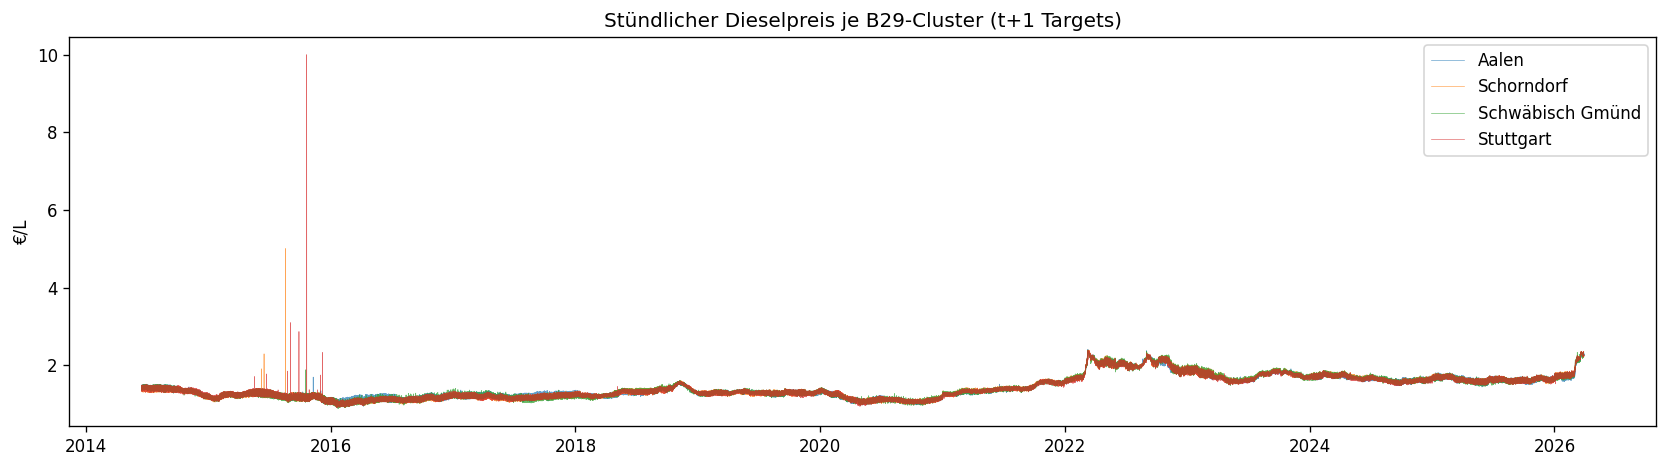

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
for col in y_t1.columns:
    ax.plot(y_t1.index, y_t1[col], lw=0.4, alpha=0.7, label=col.replace('diesel_', ''))
ax.set(title='Stündlicher Dieselpreis je B29-Cluster (t+1 Targets)',
       ylabel='€/L', xlabel='')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()

save_plot(plt, title_suffix='diesel_price_historical_t_plus_1', fig_id=fig_id)
plt.show()

Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-53-46_diesel_intraday_t_plus_1_1.png


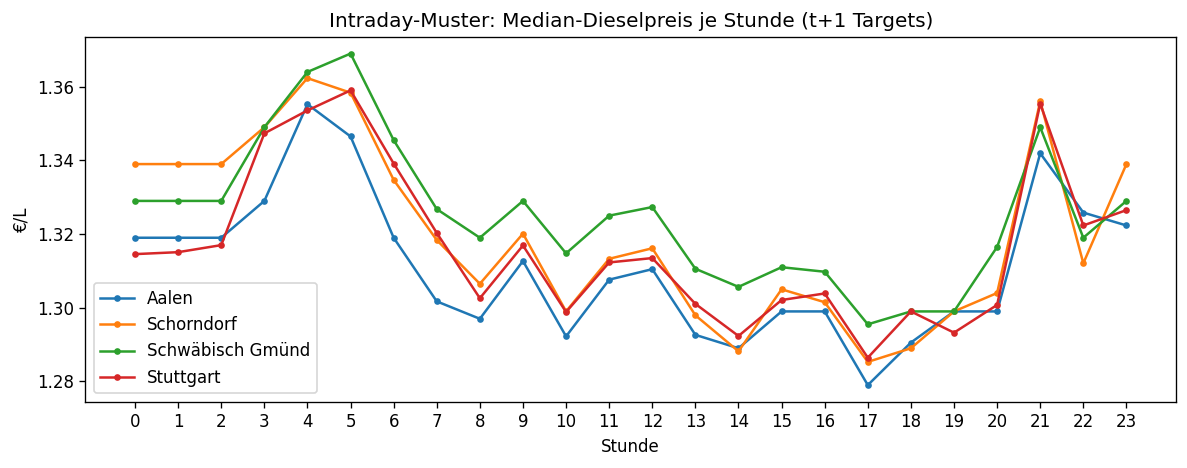

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for col in y_t1.columns:
    intraday = y_t1[col].groupby(y_t1.index.hour).median()
    ax.plot(intraday.index, intraday.values, marker='o', ms=3,
            label=col.replace('diesel_', ''))
ax.set(title='Intraday-Muster: Median-Dieselpreis je Stunde (t+1 Targets)',
       xlabel='Stunde', ylabel='€/L')
ax.set_xticks(range(0, 24, 1))
ax.legend()
plt.tight_layout()
save_plot(plt, title_suffix='diesel_intraday_t_plus_1', fig_id=fig_id)
plt.show()

Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-53-46_diesel_cluster_correlation_t_plus_1_1.png


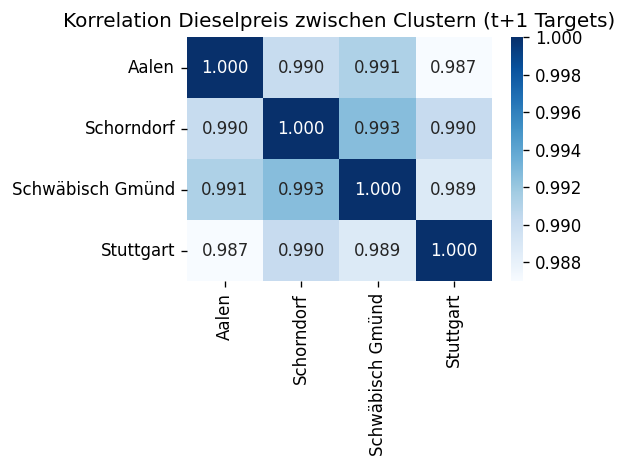

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(y_t1.corr(), annot=True, fmt='.3f', cmap='Blues', ax=ax,
            xticklabels=[c.replace('diesel_', '') for c in y_t1.columns],
            yticklabels=[c.replace('diesel_', '') for c in y_t1.columns])
ax.set_title('Korrelation Dieselpreis zwischen Clustern (t+1 Targets)')
plt.tight_layout()
save_plot(plt, title_suffix='diesel_cluster_correlation_t_plus_1', fig_id=fig_id)
plt.show()

---
## §3 Data Preparation

Der `B29DataLoader` hat bereits alle Features berechnet (Lags, Rolling, Trend, Momentum, Zeitmerkmale).  
Hier prüfen wir die Feature-Matrix und führen den Temporal-Split durch.

In [10]:
print(f'Feature-Matrix X: {X.shape}')
print(f'Target-Matrix  y: {y.shape}')
print(f'Anzahl Basis-Cluster: {len(base_targets)}')
print(f'Anzahl Horizonte je Cluster: {TARGET_HORIZON}')

lag_cols     = [c for c in X.columns if '_lag_' in c]
price_t_cols = [c for c in X.columns if c.endswith('_price_t')]
roll_cols    = [c for c in X.columns if '_roll_' in c]
diff_cols    = [c for c in X.columns if '_diff' in c or '_momentum' in c]
trend_cols   = [c for c in X.columns if '_trend' in c]
time_cols    = ['hour', 'day_of_week', 'is_weekend', 'is_holiday']

print(f'  Lag-Features        : {len(lag_cols):3d} Spalten')
print(f'  Price_t-Features    : {len(price_t_cols):3d} Spalten')
print(f'  Rolling-Features    : {len(roll_cols):3d} Spalten')
print(f'  Diff/Momentum       : {len(diff_cols):3d} Spalten')
print(f'  Trend               : {len(trend_cols):3d} Spalten')
print(f'  Zeitmerkmale        : {len(time_cols):3d} Spalten')
print(f'  ──────────────────────────────')
print(f'  Total               : {X.shape[1]:3d} Spalten')

print('\nBeispiel-Targets:')
for col in y.columns[:min(12, len(y.columns))]:
    print(f'  {col}')

Feature-Matrix X: (103317, 80)
Target-Matrix  y: (103317, 288)
Anzahl Basis-Cluster: 4
Anzahl Horizonte je Cluster: 72
  Lag-Features        :  36 Spalten
  Price_t-Features    :   4 Spalten
  Rolling-Features    :  24 Spalten
  Diff/Momentum       :   8 Spalten
  Trend               :   4 Spalten
  Zeitmerkmale        :   4 Spalten
  ──────────────────────────────
  Total               :  80 Spalten

Beispiel-Targets:
  diesel_Aalen_t+1h
  diesel_Schorndorf_t+1h
  diesel_Schwäbisch Gmünd_t+1h
  diesel_Stuttgart_t+1h
  diesel_Aalen_t+2h
  diesel_Schorndorf_t+2h
  diesel_Schwäbisch Gmünd_t+2h
  diesel_Stuttgart_t+2h
  diesel_Aalen_t+3h
  diesel_Schorndorf_t+3h
  diesel_Schwäbisch Gmünd_t+3h
  diesel_Stuttgart_t+3h


In [11]:
# Check for remaining NaN after warmup drop
nan_count = X.isna().sum().sum()
print(f'NaN in X: {nan_count}  ({nan_count/X.size*100:.2f}%)')
if nan_count > 0:
    print('Columns with NaN:')
    print(X.isna().sum()[X.isna().sum() > 0])

NaN in X: 0  (0.00%)


In [12]:
# Drop any remaining NaN rows (should be zero or very few)
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Temporal split
X_train, X_val, X_test, y_train, y_val, y_test = loader.train_val_test_split(X, y)

print(f'\nFeature-Spalten:')
for col in X.columns:
    print(f'  {col}')

  Train : 2014-06-16 00:00:00  →  2021-12-31 23:00:00  (66,144 rows)
  Val   : 2022-01-01 00:00:00  →  2023-12-31 23:00:00  (17,520 rows)
  Test  : 2024-01-01 00:00:00  →  2026-03-29 20:00:00  (19,653 rows)

Feature-Spalten:
  diesel_Aalen_lag_1h
  diesel_Aalen_lag_2h
  diesel_Aalen_lag_3h
  diesel_Aalen_lag_6h
  diesel_Aalen_lag_12h
  diesel_Aalen_lag_24h
  diesel_Aalen_lag_48h
  diesel_Aalen_lag_72h
  diesel_Aalen_lag_168h
  diesel_Aalen_price_t
  diesel_Aalen_diff
  diesel_Aalen_roll_mean_6h
  diesel_Aalen_roll_std_6h
  diesel_Aalen_roll_mean_24h
  diesel_Aalen_roll_std_24h
  diesel_Aalen_roll_mean_48h
  diesel_Aalen_roll_std_48h
  diesel_Aalen_trend
  diesel_Aalen_momentum
  diesel_Schorndorf_lag_1h
  diesel_Schorndorf_lag_2h
  diesel_Schorndorf_lag_3h
  diesel_Schorndorf_lag_6h
  diesel_Schorndorf_lag_12h
  diesel_Schorndorf_lag_24h
  diesel_Schorndorf_lag_48h
  diesel_Schorndorf_lag_72h
  diesel_Schorndorf_lag_168h
  diesel_Schorndorf_price_t
  diesel_Schorndorf_diff
  diesel_Sch

In [13]:
# Scale features (fit only on train set to avoid leakage)
# alle input-Features werden mit StandardScaler skaliert
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
# y_test bleibt unscaled für finale Evaluation

print('Scaler fitted on train set only — kein Data Leakage.')

Scaler fitted on train set only — kein Data Leakage.


---
## §4 Modeling

In [14]:
# Baseline: DummyRegressor (mean prediction)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_s, y_train_s)

y_val_dummy = scaler_y.inverse_transform(dummy.predict(X_val_s))
dummy_mae = mean_absolute_error(y_val, y_val_dummy, multioutput='uniform_average')
dummy_r2  = r2_score(y_val, y_val_dummy, multioutput='uniform_average')
print(f'Baseline (DummyRegressor mean):')
print(f'  Val MAE = {dummy_mae:.4f} €/L')
print(f'  Val R²  = {dummy_r2:.4f}')

Baseline (DummyRegressor mean):
  Val MAE = 0.6173 €/L
  Val R²  = -10.9984


In [15]:
mlp_cv = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=False,
)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    mlp_cv, X_train_s, y_train_s,
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae = -cv_scores
print('TimeSeriesSplit CV (5 Folds) — MAE auf skalierten Multi-Horizon-Targets:')
print(f'  Folds : {np.round(cv_mae, 5)}')
print(f'  Mean  : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}')

TimeSeriesSplit CV (5 Folds) — MAE auf skalierten Multi-Horizon-Targets:
  Folds : [0.24026 0.15872 0.20593 0.18076 0.1557 ]
  Mean  : 0.18828 ± 0.03164


Iteration 1, loss = 0.06704748
Validation score: 0.930639
Iteration 2, loss = 0.03704284
Validation score: 0.939034
Iteration 3, loss = 0.03403571
Validation score: 0.943760
Iteration 4, loss = 0.03226641
Validation score: 0.945822
Iteration 5, loss = 0.03157640
Validation score: 0.948024
Iteration 6, loss = 0.03064419
Validation score: 0.949351
Iteration 7, loss = 0.03003840
Validation score: 0.950442
Iteration 8, loss = 0.02958064
Validation score: 0.951491
Iteration 9, loss = 0.02914416
Validation score: 0.951698
Iteration 10, loss = 0.02884635
Validation score: 0.951582
Iteration 11, loss = 0.02862275
Validation score: 0.952685
Iteration 12, loss = 0.02833329
Validation score: 0.952857
Iteration 13, loss = 0.02800233
Validation score: 0.953889
Iteration 14, loss = 0.02777133
Validation score: 0.953231
Iteration 15, loss = 0.02753801
Validation score: 0.954093
Iteration 16, loss = 0.02729729
Validation score: 0.955121
Iteration 17, loss = 0.02703934
Validation score: 0.955408
Iterat

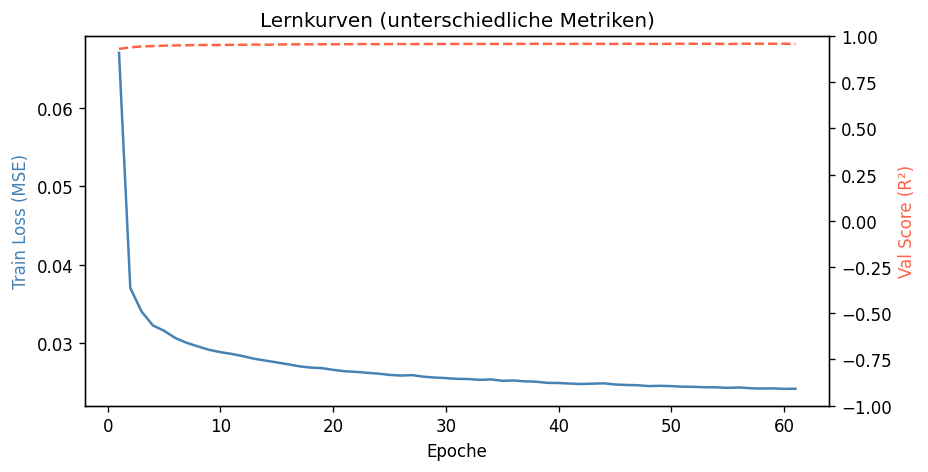

Validation Performance je vorhergesagter Stunde:
               MAE     RMSE       R2
horizon_h                           
1          0.02711  0.03571  0.96324
2          0.03113  0.04104  0.95137
3          0.03376  0.04501  0.94150
4          0.03041  0.04040  0.95291
5          0.03139  0.04263  0.94758
6          0.02897  0.03918  0.95572
7          0.02987  0.03986  0.95414
8          0.03286  0.04364  0.94507
9          0.03245  0.04361  0.94515
10         0.03062  0.04118  0.95104
...
               MAE     RMSE       R2
horizon_h                           
68         0.03400  0.04599  0.93881
69         0.03626  0.04924  0.92971
70         0.03232  0.04462  0.94236
71         0.03551  0.04831  0.93235
72         0.03892  0.05289  0.91888

Validation Gesamt (Ø über alle vorhergesagte Stunden): MAE=0.03411 €/L, RMSE=0.04576, R²=0.9385


In [16]:
model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True,
)
model.fit(X_train_s, y_train_s)

print('Effektive Epochen:', model.n_iter_)
print('Final loss:', model.loss_)

epochs = np.arange(1, len(model.loss_curve_) + 1)
fig, ax1 = plt.subplots(figsize=(8, 4))

# Linke Achse: Train Loss (MSE)
ax1.plot(epochs, model.loss_curve_, color='steelblue', label='Train Loss (MSE)')
ax1.set_ylabel('Train Loss (MSE)', color='steelblue')

# Rechte Achse: Val Score (R2)
if hasattr(model, 'validation_scores_'):
    ax2 = ax1.twinx()
    ax2.plot(epochs[:len(model.validation_scores_)], model.validation_scores_, 
             ls='--', color='tomato', label='Val Score (R²)')
    ax2.set_ylabel('Val Score (R²)', color='tomato')
    ax2.set_ylim(-1, 1) # R2 sinnvoll begrenzen

ax1.set_xlabel('Epoche')
plt.title('Lernkurven (unterschiedliche Metriken)')
save_plot(plt, title_suffix='diesel_mlp_loss_curve', fig_id=fig_id)
plt.show()

y_val_pred = scaler_y.inverse_transform(model.predict(X_val_s))
y_val_pred = pd.DataFrame(y_val_pred, index=y_val.index, columns=y.columns)

horizons = list(range(1, TARGET_HORIZON + 1))
val_rows = []
for step in horizons:
    cols = [f'{cluster}_t+{step}h' for cluster in base_targets]
    mae = mean_absolute_error(y_val[cols], y_val_pred[cols], multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_val[cols], y_val_pred[cols], multioutput='uniform_average'))
    r2 = r2_score(y_val[cols], y_val_pred[cols], multioutput='uniform_average')
    val_rows.append({'horizon_h': step, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

val_metrics_by_h = pd.DataFrame(val_rows).set_index('horizon_h')
print('Validation Performance je vorhergesagter Stunde:')
print(val_metrics_by_h.head(10).round(5))
print('...')
print(val_metrics_by_h.tail(5).round(5))
print(f"\nValidation Gesamt (Ø über alle vorhergesagte Stunden): MAE={val_metrics_by_h['MAE'].mean():.5f} €/L, RMSE={val_metrics_by_h['RMSE'].mean():.5f}, R²={val_metrics_by_h['R2'].mean():.4f}")

---
## §5 Evaluation (Test-Set — einmalig geöffnet)

In [17]:
y_test_pred = scaler_y.inverse_transform(model.predict(X_test_s))
y_test_pred = pd.DataFrame(y_test_pred, index=y_test.index, columns=y.columns)

test_rows = []
for step in range(1, TARGET_HORIZON + 1):
    cols = [f'{cluster}_t+{step}h' for cluster in base_targets]
    mae = mean_absolute_error(y_test[cols], y_test_pred[cols], multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_test[cols], y_test_pred[cols], multioutput='uniform_average'))
    r2 = r2_score(y_test[cols], y_test_pred[cols], multioutput='uniform_average')
    test_rows.append({'horizon_h': step, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

test_metrics_by_h = pd.DataFrame(test_rows).set_index('horizon_h')

persist_pred_test = pd.DataFrame(index=y_test.index, columns=y.columns, dtype=float)
for step in range(1, TARGET_HORIZON + 1):
    for cluster in base_targets:
        persist_pred_test[f'{cluster}_t+{step}h'] = X_test[f'{cluster}_price_t'].values

persist_rows = []
for step in range(1, TARGET_HORIZON + 1):
    cols = [f'{cluster}_t+{step}h' for cluster in base_targets]
    mae = mean_absolute_error(y_test[cols], persist_pred_test[cols], multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(y_test[cols], persist_pred_test[cols], multioutput='uniform_average'))
    r2 = r2_score(y_test[cols], persist_pred_test[cols], multioutput='uniform_average')
    persist_rows.append({'horizon_h': step, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

persist_metrics_by_h = pd.DataFrame(persist_rows).set_index('horizon_h')

print('Test Performance je Horizont (2024–2026): MLP')
print(test_metrics_by_h.head(10).round(5))
print('...')
print(test_metrics_by_h.tail(5).round(5))
print(f"\nMLP Test Gesamt (Ø über Horizonte): MAE={test_metrics_by_h['MAE'].mean():.5f} €/L, RMSE={test_metrics_by_h['RMSE'].mean():.5f}, R²={test_metrics_by_h['R2'].mean():.4f}")

print('\nTest Performance je Horizont (2024–2026): Persistence')
print(persist_metrics_by_h.head(10).round(5))
print('...')
print(persist_metrics_by_h.tail(5).round(5))
print(f"\nPersistence Test Gesamt (Ø über Horizonte): MAE={persist_metrics_by_h['MAE'].mean():.5f} €/L, RMSE={persist_metrics_by_h['RMSE'].mean():.5f}, R²={persist_metrics_by_h['R2'].mean():.4f}")

comparison_overall = pd.DataFrame({
    'MAE': [test_metrics_by_h['MAE'].mean(), persist_metrics_by_h['MAE'].mean()],
    'RMSE': [test_metrics_by_h['RMSE'].mean(), persist_metrics_by_h['RMSE'].mean()],
    'R2': [test_metrics_by_h['R2'].mean(), persist_metrics_by_h['R2'].mean()]
}, index=['MLP', 'Persistence'])

print('\nGesamtvergleich MLP vs Persistence (Ø über Horizonte):')
print(comparison_overall.round(5))

mae_improvement_vs_persistence = (persist_metrics_by_h['MAE'].mean() - test_metrics_by_h['MAE'].mean()) / persist_metrics_by_h['MAE'].mean() * 100
rmse_skill_vs_persistence = 1 - (test_metrics_by_h['RMSE'].mean() / persist_metrics_by_h['RMSE'].mean())
print(f'\nVerbesserung ggü. Persistence (MAE): {mae_improvement_vs_persistence:.1f}%')
print(f'Skill ggü. Persistence (RMSE): {rmse_skill_vs_persistence:.1%}')
print(f'Fleet-Kostenfehler/Tag (Ø-MAE, MLP): {test_metrics_by_h["MAE"].mean() * DAILY_LITERS:.2f} €')

Test Performance je Horizont (2024–2026): MLP
               MAE     RMSE       R2
horizon_h                           
1          0.02320  0.03005  0.93753
2          0.02445  0.03147  0.93143
3          0.02801  0.03592  0.91045
4          0.02530  0.03241  0.92728
5          0.02671  0.03453  0.91719
6          0.02447  0.03179  0.93012
7          0.02495  0.03250  0.92706
8          0.02671  0.03522  0.91467
9          0.02735  0.03534  0.91385
10         0.02578  0.03354  0.92267
...
               MAE     RMSE       R2
horizon_h                           
68         0.02708  0.03768  0.90997
69         0.02656  0.03862  0.90657
70         0.02340  0.03487  0.92338
71         0.02560  0.03740  0.91223
72         0.02656  0.03981  0.90118

MLP Test Gesamt (Ø über Horizonte): MAE=0.02686 €/L, RMSE=0.03643, R²=0.9113

Test Performance je Horizont (2024–2026): Persistence
               MAE     RMSE       R2
horizon_h                           
1          0.02075  0.02815  0.94455
2  

Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-55-58_mlp_vs_persistence_metrics_by_horizon_test_1.png


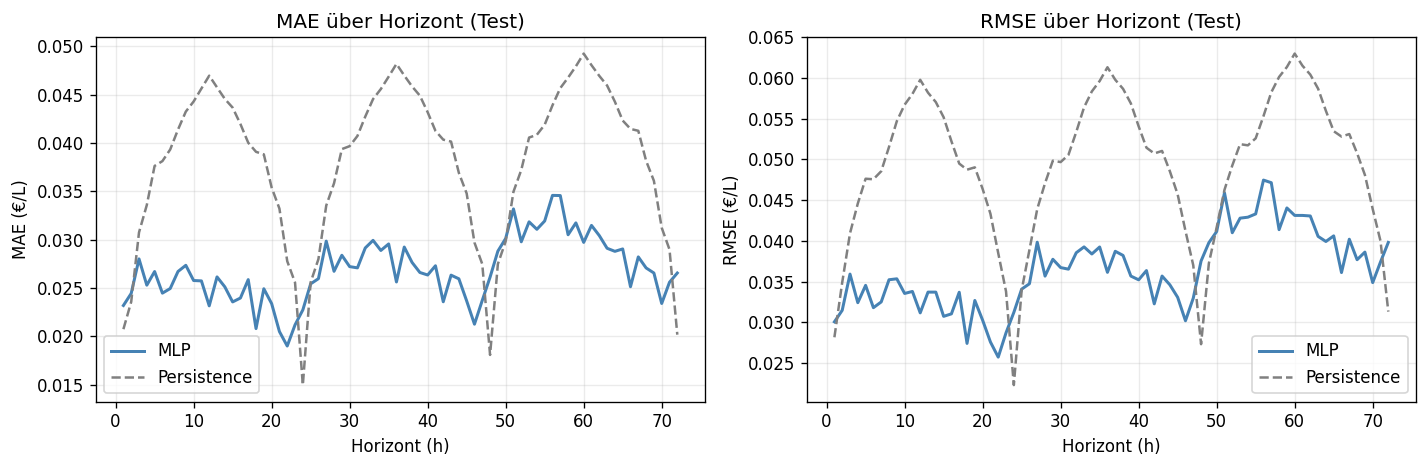

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(test_metrics_by_h.index, test_metrics_by_h['MAE'], label='MLP', color='steelblue', lw=1.8)
axes[0].plot(persist_metrics_by_h.index, persist_metrics_by_h['MAE'], label='Persistence', color='gray', lw=1.5, ls='--')
axes[0].set_title('MAE über Horizont (Test)')
axes[0].set_xlabel('Horizont (h)')
axes[0].set_ylabel('MAE (€/L)')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(test_metrics_by_h.index, test_metrics_by_h['RMSE'], label='MLP', color='steelblue', lw=1.8)
axes[1].plot(persist_metrics_by_h.index, persist_metrics_by_h['RMSE'], label='Persistence', color='gray', lw=1.5, ls='--')
axes[1].set_title('RMSE über Horizont (Test)')
axes[1].set_xlabel('Horizont (h)')
axes[1].set_ylabel('RMSE (€/L)')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
save_plot(plt, title_suffix='mlp_vs_persistence_metrics_by_horizon_test', fig_id=fig_id)
plt.show()

Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-55-59_diesel_price_predictions_t_plus_1_test_set_1.png


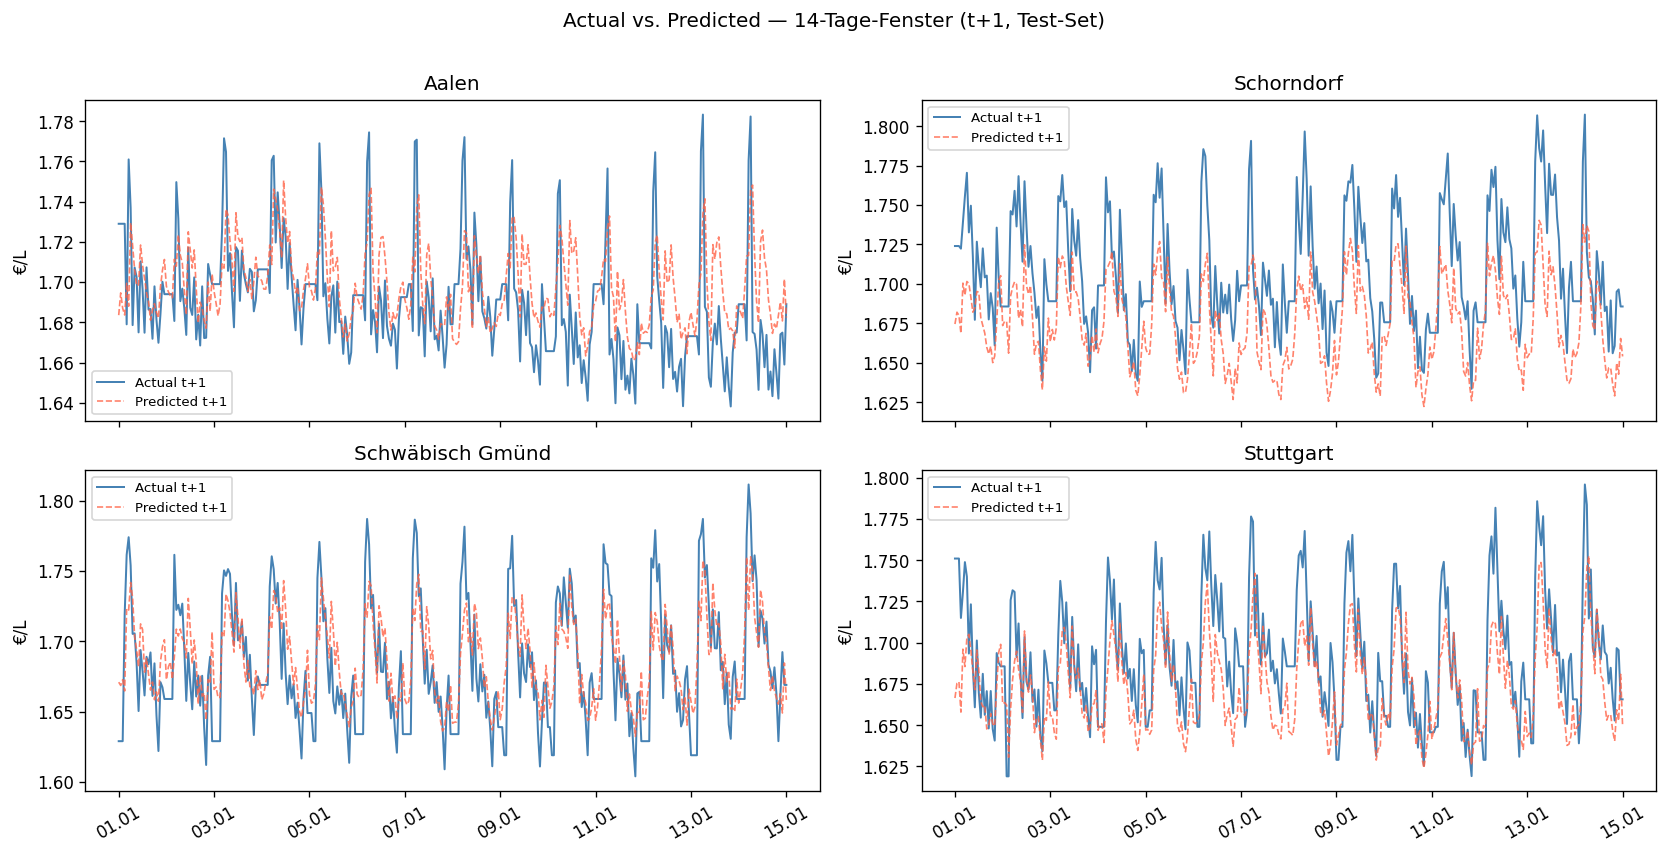

In [19]:
sample_start = y_test.index[0]
sample_end = y_test.index[0] + pd.Timedelta(days=14)

y_test_t1 = y_test[[f'{c}_t+1h' for c in base_targets]].copy()
y_test_t1.columns = base_targets
y_pred_t1 = y_test_pred[[f'{c}_t+1h' for c in base_targets]].copy()
y_pred_t1.columns = base_targets

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, col in zip(axes.flat, y_test_t1.columns):
    label = col.replace('diesel_', '')
    mask = (y_test_t1.index >= sample_start) & (y_test_t1.index <= sample_end)
    ax.plot(y_test_t1.index[mask], y_test_t1.loc[mask, col], lw=1.2,
            label='Actual t+1', color='steelblue')
    ax.plot(y_pred_t1.index[mask], y_pred_t1.loc[mask, col],
            lw=1, ls='--', label='Predicted t+1', color='tomato', alpha=0.8)
    ax.set_title(label)
    ax.set_ylabel('€/L')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Actual vs. Predicted — 14-Tage-Fenster (t+1, Test-Set)', y=1.01)
plt.tight_layout()
save_plot(plt, title_suffix='diesel_price_predictions_t_plus_1_test_set', fig_id=fig_id)
plt.show()

Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-55-59_diesel_price_residuals_t_plus_1_1.png


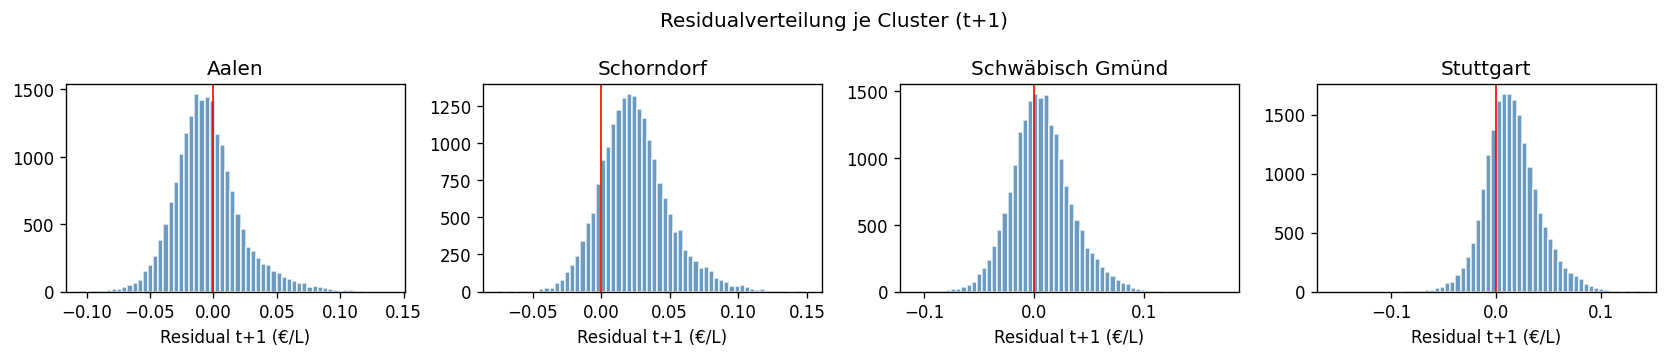

In [20]:
residuals_t1 = y_test_t1 - y_pred_t1

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, residuals_t1.columns):
    ax.hist(residuals_t1[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(col.replace('diesel_', ''))
    ax.set_xlabel('Residual t+1 (€/L)')
fig.suptitle('Residualverteilung je Cluster (t+1)')
plt.tight_layout()
save_plot(plt, title_suffix='diesel_price_residuals_t_plus_1', fig_id=fig_id)
plt.show()

---
## §6 Deployment: Direkte 72h-Forecast je B29-Cluster

Direkte Vorhersage der nächsten 72 Stunden in einem Schritt.  
Empfehlung: **Wo** und **wann** auf der B29 tanken?

In [21]:
def forecast_72h_direct(
    model,
    scaler_X: StandardScaler,
    scaler_y: StandardScaler,
    X: pd.DataFrame,
    y_columns: list[str],
    base_targets: list[str],
    horizon: int = 72,
) -> pd.DataFrame:
    x_last = X.iloc[[-1]].copy()
    x_scaled = scaler_X.transform(x_last)
    y_scaled = model.predict(x_scaled)
    y_pred_all = scaler_y.inverse_transform(y_scaled)

    pred = pd.Series(y_pred_all[0], index=y_columns)
    last_ts = X.index[-1]

    rows = []
    for step in range(1, horizon + 1):
        ts = last_ts + pd.Timedelta(hours=step)
        row = {'timestamp': ts}
        for cluster in base_targets:
            row[cluster] = pred[f'{cluster}_t+{step}h']
        rows.append(row)

    df_fc = pd.DataFrame(rows).set_index('timestamp')
    return df_fc


df_forecast = forecast_72h_direct(
    model,
    scaler_X,
    scaler_y,
    X_test,
    y.columns.tolist(),
    base_targets,
    horizon=TARGET_HORIZON
)
print(f'Forecast shape: {df_forecast.shape}')
df_forecast.head()

Forecast shape: (72, 4)


,diesel_Aalen,diesel_Schorndorf,diesel_Schwäbisch Gmünd,diesel_Stuttgart
timestamp,,,,
2026-03-29 21:00:00,2.294554,2.211454,2.263351,2.241261
2026-03-29 22:00:00,2.248098,2.149759,2.244790,2.221317
2026-03-29 23:00:00,2.247918,2.165124,2.224712,2.211127
2026-03-30 00:00:00,2.303790,2.207792,2.264793,2.253100
2026-03-30 01:00:00,2.297827,2.219436,2.266611,2.247986


Plot saved to: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-27-17-56-00_diesel_price_forecast_72h_direct_1.png


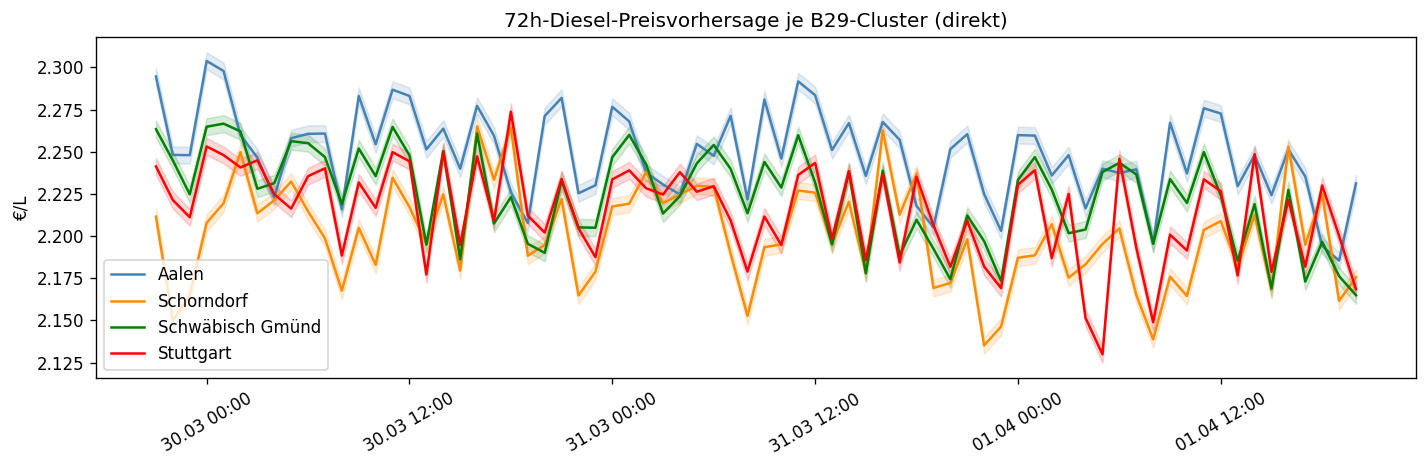

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green', 'red']

for col, color in zip(df_forecast.columns, colors):
    label = col.replace('diesel_', '')
    ax.plot(df_forecast.index, df_forecast[col], lw=1.5, label=label, color=color)
    ax.fill_between(df_forecast.index, df_forecast[col] - 0.005,
                    df_forecast[col] + 0.005, alpha=0.15, color=color)

ax.set(title='72h-Diesel-Preisvorhersage je B29-Cluster (direkt)',
       ylabel='€/L', xlabel='')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
save_plot(plt, title_suffix='diesel_price_forecast_72h_direct', fig_id=fig_id)
plt.show()

In [23]:
min_price_per_cluster = df_forecast.min()
min_time_per_cluster = df_forecast.idxmin()
best_cluster = min_price_per_cluster.idxmin().replace('diesel_', '')
best_time = min_time_per_cluster[min_price_per_cluster.idxmin()]
best_price = min_price_per_cluster.min()
current_price = df_forecast.iloc[0].mean()

print('=== Tankempfehlung für die nächsten 72 Stunden ===')
print()
for col in df_forecast.columns:
    cluster = col.replace('diesel_', '')
    p_min = df_forecast[col].min()
    t_min = df_forecast[col].idxmin()
    print(f'  {cluster:22s}: {p_min:.4f} €/L  um {t_min.strftime("%d.%m.%Y %H:%M")}')

print()
print(f'>>> Empfehlung: {best_cluster} um {best_time.strftime("%d.%m.%Y %H:%M")} Uhr')
print(f'    Günstigster Preis : {best_price:.4f} €/L')
print(f'    Jetziger Schnitt  : {current_price:.4f} €/L')
saving = (current_price - best_price) * DAILY_LITERS
print(f'    Einsparung/Tag    : {saving:.2f} € ({current_price - best_price:.4f} €/L × {DAILY_LITERS:.0f} L)')

=== Tankempfehlung für die nächsten 72 Stunden ===

  Aalen                 : 2.1854 €/L  um 01.04.2026 19:00
  Schorndorf            : 2.1351 €/L  um 31.03.2026 22:00
  Schwäbisch Gmünd      : 2.1649 €/L  um 01.04.2026 20:00
  Stuttgart             : 2.1298 €/L  um 01.04.2026 05:00

>>> Empfehlung: Stuttgart um 01.04.2026 05:00 Uhr
    Günstigster Preis : 2.1298 €/L
    Jetziger Schnitt  : 2.2527 €/L
    Einsparung/Tag    : 36.84 € (0.1228 €/L × 300 L)
